IT25101557_Encoding_Categorical_Variables
HIRUNI KAWYA — Individual Preprocessing Component

Technique: Encoding Categorical Variables

Why this technique was needed
Machine-learning algorithms (KNN, logistic regression, SVM, gradient boosting, etc.) require
numeric input. The assigned dataset has 7 categorical columns
(`gender`, `ethnicity`, `education_level`, `income_level`, `employment_status`,
`smoking_status`, `diabetes_stage`). Some are nominal (no natural order — e.g. `ethnicity`)
and some are ordinal (a natural order exists — e.g. `income_level`,
`education_level`, `diabetes_stage`). Choosing the right encoding for each type matters:
one-hot encoding a variable with an order would throw away useful information, and
label/ordinal-encoding a nominal variable would invent a false order the model might learn
from.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../results/outputs/stage1_missing_data_checked.csv')
print(df.shape)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
df[cat_cols].nunique()

(97297, 31)
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']


gender               3
ethnicity            5
education_level      4
income_level         5
employment_status    4
smoking_status       3
diabetes_stage       5
dtype: int64

Step 1 - Classify each categorical column as nominal or ordinal

In [2]:
encoding_plan = pd.DataFrame({
    'column': ['gender', 'ethnicity', 'education_level', 'income_level',
               'employment_status', 'smoking_status', 'diabetes_stage'],
    'type': ['nominal', 'nominal', 'ordinal', 'ordinal',
             'nominal', 'ordinal', 'ordinal'],
    'chosen_encoding': ['One-Hot', 'One-Hot', 'Ordinal (mapped)', 'Ordinal (mapped)',
                         'One-Hot', 'Ordinal (mapped)', 'Ordinal (mapped, target)']
})
encoding_plan

,column,type,chosen_encoding
0,gender,nominal,One-Hot
1,ethnicity,nominal,One-Hot
2,education_level,ordinal,Ordinal (mapped)
3,income_level,ordinal,Ordinal (mapped)
4,employment_status,nominal,One-Hot
5,smoking_status,ordinal,Ordinal (mapped)
6,diabetes_stage,ordinal,"Ordinal (mapped, target)"


Step 2 - Ordinal encoding for naturally-ordered categories

In [3]:
education_order = {'No formal': 0, 'Highschool': 1, 'Graduate': 2, 'Postgraduate': 3}
income_order = {'Low': 0, 'Lower-Middle': 1, 'Middle': 2, 'Upper-Middle': 3, 'High': 4}
smoking_order = {'Never': 0, 'Former': 1, 'Current': 2}
diabetes_stage_order = {'No Diabetes': 0, 'Pre-Diabetes': 1, 'Gestational': 2, 'Type 2': 3, 'Type 1': 4}

df_enc = df.copy()
df_enc['education_level'] = df_enc['education_level'].map(education_order)
df_enc['income_level'] = df_enc['income_level'].map(income_order)
df_enc['smoking_status'] = df_enc['smoking_status'].map(smoking_order)
df_enc['diabetes_stage_encoded'] = df_enc['diabetes_stage'].map(diabetes_stage_order)

print("Any unmapped (NaN) values introduced?", df_enc[['education_level','income_level',
      'smoking_status','diabetes_stage_encoded']].isnull().sum().sum())
df_enc[['education_level', 'income_level', 'smoking_status', 'diabetes_stage', 'diabetes_stage_encoded']].head()

Any unmapped (NaN) values introduced? 0


,education_level,income_level,smoking_status,diabetes_stage,diabetes_stage_encoded
0,1,1,0,Type 2,3
1,1,2,1,No Diabetes,0
2,1,2,0,Type 2,3
3,1,0,0,Type 2,3
4,2,2,0,Type 2,3


Step 3 - One-hot encoding for nominal categories

In [4]:
nominal_cols = ['gender', 'ethnicity', 'employment_status']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, prefix=nominal_cols, drop_first=False)

new_onehot_cols = [c for c in df_enc.columns if any(c.startswith(p + '_') for p in nominal_cols)]
print(f"Created {len(new_onehot_cols)} one-hot columns:")
print(new_onehot_cols)
df_enc[new_onehot_cols].head()

Created 12 one-hot columns:
['gender_Female', 'gender_Male', 'gender_Other', 'ethnicity_Asian', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'employment_status_Employed', 'employment_status_Retired', 'employment_status_Student', 'employment_status_Unemployed']


,gender_Female,gender_Male,gender_Other,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,False,True,False,True,False,False,False,False,True,False,False,False
1,True,False,False,False,False,False,False,True,True,False,False,False
2,False,True,False,False,False,True,False,False,False,False,False,True
3,True,False,False,False,True,False,False,False,False,True,False,False
4,False,True,False,False,False,False,False,True,False,True,False,False


EDA Visualization - Category frequency before encoding (target: diabetes_stage) and by gender

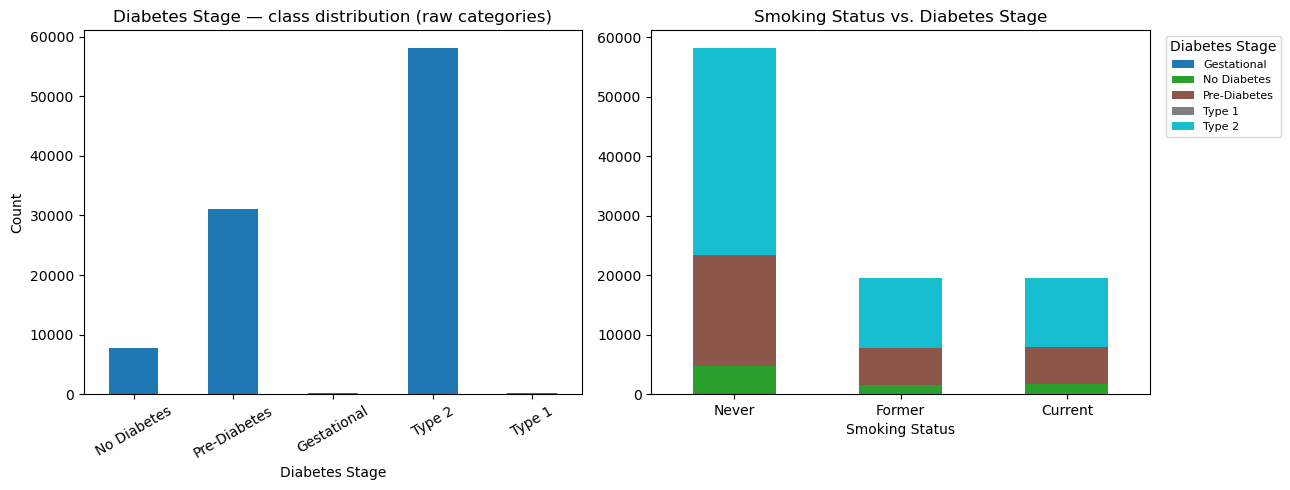

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 2', 'Type 1']
df['diabetes_stage'].value_counts().reindex(order).plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('Diabetes Stage — class distribution (raw categories)')
axes[0].set_xlabel('Diabetes Stage')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

pd.crosstab(df['smoking_status'], df['diabetes_stage']).reindex(
    ['Never', 'Former', 'Current']
).plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Smoking Status vs. Diabetes Stage')
axes[1].set_xlabel('Smoking Status')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Diabetes Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/eda_visualizations/categorical_distributions.png', dpi=120)
plt.show()

Interpretation
The class distribution is heavily imbalanced: Type 2 and Pre-Diabetes dominate while
Gestational and Type 1 are rare (<0.3% and <0.1% of rows respectively) — this directly
informs the group's later decision to apply SMOTE before model training. The stacked bar chart
shows the proportion of each diabetes stage is visibly higher among Current smokers than
Never smokers, which is consistent with smoking as a known diabetes risk factor and justifies
keeping smoking_status as an ordinal (not dropped) feature.

Conclusion
Ordinal encoding was applied to education_level, income_level, smoking_status, and the
  target diabetes_stage (order preserved, no information loss).
One-hot encoding was applied to the purely nominal columns gender, ethnicity, and
  employment_status (no false ordering introduced).
Verified zero NaNs were introduced by the mapping step.
The fully encoded dataframe is passed forward to the group pipeline for outlier handling and
  scaling.

In [6]:
df_enc.to_csv('../results/outputs/stage2_encoded.csv', index=False)
print("Saved encoded dataset for the group pipeline:", df_enc.shape)

Saved encoded dataset for the group pipeline: (97297, 41)
